# AI-Generated Text Classification Pipeline
## Detecting which AI model generated a given text

This notebook implements a comprehensive machine learning pipeline to distinguish between texts generated by different AI models (Human, DeepSeek, Grok, Claude, Gemini, ChatGPT). The approach combines advanced feature engineering, Bayesian hyperparameter optimization, and ensemble learning techniques.

### Problem Overview
- **Task**: Multi-class classification (6 classes)
- **Challenge**: Unbalanced dataset with subtle differences between AI-generated text styles
- **Solution**: Feature engineering + LightGBM + Stacking with calibration

In [ ]:
# ==============================================================================
# IMPORTS AND DEPENDENCIES
# ==============================================================================
# Core data manipulation and numerical computing libraries
import numpy as np
import pandas as pd

# Scikit-learn pipeline and preprocessing tools
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

# Ensemble methods and model calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# LightGBM - I chose this for its efficiency and performance on text classification
from lightgbm import LGBMClassifier

# Visualization libraries
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Custom utilities for feature engineering
# - featureExtractor: performs text preprocessing and feature extraction
# - Chi2TextFeatureSelector: implements ImpCHI feature selection algorithm
from utils.featureExtractor import featureExtractor
from utils.impChi import Chi2TextFeatureSelector

# ==============================================================================
# CLASS MAPPING
# ==============================================================================
# I create a dictionary mapping numeric labels to model names for readability
diz = {
    0: 'Human',
    1: 'DeepSeek',
    2: 'Grok',   
    3: 'Claude',
    4: 'Gemini',
    5: 'ChatGPT',
}

In [ ]:
# ==============================================================================
# DATA LOADING
# ==============================================================================
# I load the training and test datasets
# Both contain text samples and their corresponding labels (which AI model generated them)
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
print(f"\nClass distribution in training set:")
print(train['LABEL'].value_counts().sort_index())

Training set shape: (2400, 2)
Test set shape: (600, 2)

Class distribution in training set:
LABEL
0    1520
1      80
2     160
3      80
4     240
5     320
Name: count, dtype: int64


## Data Preparation: Train-Test Split

I use stratified sampling to maintain class distribution across train and test sets. This is crucial for imbalanced datasets to ensure representative evaluation metrics.

In [ ]:
# I perform a stratified train-test split (75% train, 25% validation)
# Using the stratify parameter ensures each class maintains its original proportion
# This is essential for imbalanced datasets to prevent biased evaluation
df_train, df_test = train_test_split(
    train, 
    test_size=0.25, 
    stratify=train['LABEL'],  # Maintains class proportions in both splits
    random_state=42  # For reproducibility
)

# I extract features (TEXT) and labels (LABEL) from both sets
X_train, y_train = df_train['TEXT'], df_train['LABEL']
X_test, y_test = df_test['TEXT'], df_test['LABEL']

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_test.shape[0]} samples")

Training set size: 1800 samples
Validation set size: 600 samples


In [ ]:
# I convert training features to DataFrame format (required by the pipeline)
X_train = pd.DataFrame(X_train)

## Feature Engineering and Selection

### Why Feature Engineering is Critical

For this imbalanced text classification task, raw text features are inadequate because:

1. **Curse of Dimensionality**: Raw bag-of-words or TF-IDF features generate thousands of dimensions, leading to:
   - Overfitting on training data (especially critical for minority classes)
   - Slow training and prediction times
   - Poor generalization to unseen data

2. **Class Imbalance**: Different AI models produce variable-length outputs with different patterns. Simply including all features means:
   - The model may learn spurious correlations for rare classes
   - Majority class features dominate learning
   - Minority classes are underrepresented

3. **Noise Reduction**: Raw text contains stopwords, typos, and uninformative patterns that add noise without signal

### Solution: ImpCHI (Improved Chi-Squared Feature Selection)

**Source**: ImpCHI is based on research in feature selection for text classification with imbalanced data. The original repository (https://github.com/Gianbattistabsn/Winter-project-DSMLL-2025-2026-ImpChi-and-W2V) implements statistical methods specifically designed for imbalanced datasets.

**Key advantages of ImpCHI over standard Chi-squared**:
- Accounts for class imbalance by computing chi-squared statistics per label
- Selects k_per_label features for each class, ensuring minority classes aren't overlooked
- Uses n-grams (1, 2, 3) to capture phrasal patterns that might distinguish AI outputs
- Applies minimum document frequency filtering (min_df) to remove extremely rare features

Our pipeline configuration:
- **k_per_label=45**: Select 45 most informative features per class (270 total if no overlap)
- **min_df=3**: Features must appear in at least 3 documents (noise reduction)
- **ngram_range=(1,3)**: Capture unigrams, bigrams, and trigrams
- **StandardScaler**: Normalize features to have zero mean and unit variance (improves model convergence even if it is not strictly needed)

In [ ]:
# ==============================================================================
# PREPROCESSING PIPELINE
# ==============================================================================

pipeline = Pipeline([
    # Basic text feature extraction and preprocessing
    ('feature_ext', featureExtractor()),
    
    # Advanced feature selection using ImpCHI
    # This dramatically reduces dimensionality while retaining discriminative power
    ('impChi', Chi2TextFeatureSelector(
        k_per_label=45,      # Select 45 best features per class
        min_df=3,             # Filter out features appearing in <3 documents
        ngram_range=(1, 3)    # Use unigrams, bigrams, and trigrams
    )),
    
    # Standardization
    ('ss', StandardScaler())
])

# Fit the pipeline on training data and transform it
X_train_pp = pipeline.fit_transform(pd.DataFrame(X_train), y_train)
X_test_pp = pipeline.transform(pd.DataFrame(X_test))

print(f"Original feature dimension: TF-IDF matrix")
print(f"After preprocessing dimension: {X_train_pp.shape[1]} features")
print(f"Training set shape after preprocessing: {X_train_pp.shape}")
print(f"Validation set shape after preprocessing: {X_test_pp.shape}")

Fitting TF-IDF (min_df=3, ngrams=(1, 3))...
Selecting top 45 features per label via Chi-Square test...
Total unique TF-IDF features selected: 257
Original feature dimension: TF-IDF matrix
After preprocessing dimension: 284 features
Training set shape after preprocessing: (1800, 284)
Validation set shape after preprocessing: (600, 284)


## Model Selection and Hyperparameter Tuning

### Why LightGBM?

LightGBM (Light Gradient Boosting Machine) was chosen for this task because:

1. **Efficiency**: Trains significantly faster than standard GBDT implementations
2. **Scalability**: Handles high-dimensional data effectively (important after feature selection)
3. **Imbalanced Data Support**: Has built-in `class_weight='balanced'` to handle imbalanced classes
4. **Feature Importance**: Provides interpretable feature importance scores
5. **Multiclass Support**: Native support for 6-class classification

### Hyperparameter Optimization Strategy

**Method**: Bayesian Optimization via Optuna with Stratified 5-Fold Cross-Validation

**Why Bayesian Optimization over Grid Search?**
- **Efficiency**: Optuna uses Bayesian optimization to intelligently explore the hyperparameter space
- **Fewer Trials**: Instead of exhaustively searching all combinations, it learns from previous trials to propose promising configurations
- **50 Trials**: A reasonable budget that balances exploration and computational cost

**Why Stratified 5-Fold CV?**
- Ensures each fold maintains class distribution (critical for imbalanced data)
- Provides robust performance estimates (average of 5 folds is more reliable than single train-val split)
- Better utilization of training data for tuning

**Hyperparameters Tuned**:
- **n_estimators**: Number of boosting rounds (trees)
- **learning_rate**: Shrinkage rate (lower = slower but potentially more accurate)
- **max_depth**: Maximum tree depth (controls model complexity)
- **num_leaves**: Maximum number of leaves per tree
- **min_child_samples**: Minimum samples required for leaf node (regularization)
- **reg_alpha, reg_lambda**: L1 and L2 regularization (prevent overfitting)
- **colsample_bytree, subsample**: Feature and sample subsampling (reduce overfitting)
- **subsample_freq**: Frequency of subsampling

In [ ]:
# ==============================================================================
# BEST HYPERPARAMETERS FOUND FROM OPTUNA OPTIMIZATION
# ==============================================================================
# After my 50 trials using Bayesian optimization with 5-fold stratified CV,
# these configurations showed the best validation performance.

# Trial 31: Conservative learning approach with shallow trees
# Strengths: Lower learning_rate and max_depth reduce overfitting risk
params_31 = {
    'objective': 'multiclass',
    'num_class': 6,
    'class_weight': 'balanced',  # Handle class imbalance
    'boosting_type': 'gbdt',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'n_estimators': 730,
    'learning_rate': 0.010407498940906855,  # Very conservative
    'max_depth': 5,  # Shallow trees
    'num_leaves': 54,
    'min_child_samples': 37,
    'min_split_gain': 0.06963977833346169,
    'reg_alpha': 0.21148540123122064,
    'reg_lambda': 0.030761881469967566,
    'colsample_bytree': 0.3518507408719965,
    'subsample': 0.9676247445281039,
    'subsample_freq': 6
}

# Trial 8: More complex model with faster learning
# Strengths: Higher learning_rate and max_depth enable me to capture complex patterns
params_8 = {
    'objective': 'multiclass',
    'num_class': 6,
    'class_weight': 'balanced',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'n_estimators': 922,
    'learning_rate': 0.00531016167886792,
    'max_depth': 8,
    'num_leaves': 50,
    'min_child_samples': 46,
    'min_split_gain': 0.09890451535072747,
    'reg_alpha': 0.013804574251952207,
    'reg_lambda': 0.2663921229953439,
    'colsample_bytree': 0.24448771356145826,
    'subsample': 0.8606974769886846,
    'subsample_freq': 5
}

## Training the Two Best Models

I use both configurations because they demonstrate **complementary strengths**:
- **Model 31** (Conservative): Generalizes better and is more robust to unseen data
- **Model 8** (Complex): Captures intricate patterns specific to the training data

By using both and later combining them (ensemble), I get the benefits of both regularization and pattern recognition.

In [ ]:
# ==============================================================================
# TRAIN THE TWO BEST MODELS
# ==============================================================================

# Model 1: Conservative approach (Trial 31)
print('Training Model 1 (Trial 31) - Conservative configuration...')
model_31 = LGBMClassifier(**params_31).fit(X_train_pp, y_train)
print("✓ Model 31 training completed")

# Model 2: Complex approach (Trial 8)
print("\nTraining Model 2 (Trial 8) - Complex configuration...")
model_8 = LGBMClassifier(**params_8).fit(X_train_pp, y_train)
print("✓ Model 8 training completed")

# ==============================================================================
# ENSEMBLE: SOFT VOTING (AVERAGING PROBABILITIES)
# ==============================================================================
# Instead of hard voting (majority class), I average the probability predictions
# This preserves the confidence information from both models

# I extract probability predictions from both models
# shape: (n_samples, n_classes) - probabilities for each class
probs_31 = model_31.predict_proba(X_test_pp)
probs_8 = model_8.predict_proba(X_test_pp)

# I average the probability predictions from both models
# This gives equal weight to both models' confidence scores
blended_probs = (probs_31 + probs_8) / 2.0

# I get final predictions by selecting the class with highest probability
final_predictions = np.argmax(blended_probs, axis=1)

# I evaluate the soft voting ensemble
print("\n" + "="*60)
print("SOFT VOTING ENSEMBLE PERFORMANCE")
print("="*60)
f1_soft = f1_score(y_test, final_predictions, average='macro')
print(f"F1 Macro Score (Soft Voting): {f1_soft:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, final_predictions, digits=4))

Training Model 1 (Trial 31) - Conservative configuration...
Model 31 training completed

Training Model 2 (Trial 8) - Complex configuration...
Model 8 training completed

SOFT VOTING ENSEMBLE PERFORMANCE
F1 Macro Score (Soft Voting): 0.9548

Detailed Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9974    0.9987       380
           1     0.7600    0.9500    0.8444        20
           2     0.9714    0.8500    0.9067        40
           3     1.0000    1.0000    1.0000        20
           4     0.9836    1.0000    0.9917        60
           5     0.9875    0.9875    0.9875        80

    accuracy                         0.9850       600
   macro avg     0.9504    0.9641    0.9548       600
weighted avg     0.9868    0.9850    0.9853       600



c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Ensemble Methods: Stacking with Calibration

### Why Stacking over Simple Averaging?

While soft voting averages probabilities, **stacking goes further**:
- Soft voting uses fixed weights (equal for both models)
- Stacking learns optimal weights for combining predictions using a meta-learner
- The meta-learner (Logistic Regression) learns when to trust which base model

### Why Calibration?

Model calibration ensures that predicted probabilities accurately reflect true likelihood of each class:
- **Uncalibrated**: A model might predict 0.6 probability but the actual occurrence rate is 0.4
- **Calibrated**: If model predicts 0.6, actual occurrence is approximately 0.6
- **Method**: Isotonic calibration (non-parametric, flexible)
- **CV**: 5-fold cross-validation during calibration prevents overfitting

### Stacking Configuration

1. **Base Estimators**: Two calibrated LGBMClassifier models
   - Each wrapped in CalibratedClassifierCV
   - 5-fold CV calibration ensures robustness
   
2. **Stack Method**: `predict_proba`
   - Uses probability outputs from base models instead of hard predictions
   - Provides richer information to the meta-learner

3. **Meta-Learner**: Logistic Regression
   - Simple, interpretable, and computationally efficient
   - `class_weight='balanced'`: Handles any residual imbalance
   - `C=0.1`: Strong regularization prevents overfitting to the meta-features

4. **Passthrough**: False
   - Original features NOT passed to meta-learner
   - Meta-learner sees ONLY base model outputs
   - Prevents meta-learner from relying on raw features

In [ ]:
# ==============================================================================
# STACKING WITH CALIBRATION
# ==============================================================================

# I define the base estimators: Two LightGBM models, each with isotonic calibration
estimators = [
    ('lgbm_31', CalibratedClassifierCV(
        LGBMClassifier(**params_31),
        method='isotonic',  # Non-parametric calibration method
        cv=5  # 5-fold cross-validation calibration
    )),
    ('lgbm_8', CalibratedClassifierCV(
        LGBMClassifier(**params_8),
        method='isotonic',  # Flexible, can handle diverse miscalibration patterns
        cv=5
    )),
]

# I define the meta-learner: Simple Logistic Regression
# This learns optimal weights for combining the two base models
meta = LogisticRegression(
    class_weight='balanced',  # Handle potential class imbalance in meta-features
    C=0.1,  # Regularization strength (higher = less regularization)
    max_iter=1000,  # Sufficient iterations for convergence
    random_state=42
)

# I create the stacking classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=5,  # 5-fold CV for generating meta-features (avoids data leakage)
    stack_method='predict_proba',  # Use probability outputs from base models
    passthrough=False,  # Do NOT include original features in meta-features
    n_jobs=-1  # Use all available processors
)

# I train the stacking ensemble
print("Training Stacking Classifier with calibration...")
stacking_clf.fit(X_train_pp, y_train)
print("✓ Stacking classifier training completed")

# I make predictions using the trained stacking ensemble
y_pred = stacking_clf.predict(X_test_pp)

# I evaluate stacking performance
print("\n" + "="*60)
print("STACKING ENSEMBLE PERFORMANCE (WITH CALIBRATION)")
print("="*60)
f1_stacking = f1_score(y_test, y_pred, average='macro')
print(f"F1 Macro Score (Stacking): {f1_stacking:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

if f1_stacking > f1_soft:
    improvement = ((f1_stacking - f1_soft) / f1_soft) * 100
    print(f"\n✓ Stacking improves over soft voting by {improvement:.2f}%")
else:
    print(f"\n⚠ Soft voting performed better. Consider ensemble diversity.")

Training Stacking Classifier with calibration...
Stacking classifier training completed


c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: U


STACKING ENSEMBLE PERFORMANCE (WITH CALIBRATION)
F1 Macro Score (Stacking): 0.9628

Detailed Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9974    0.9987       380
           1     0.8261    0.9500    0.8837        20
           2     0.9722    0.8750    0.9211        40
           3     1.0000    1.0000    1.0000        20
           4     0.9836    1.0000    0.9917        60
           5     0.9753    0.9875    0.9814        80

    accuracy                         0.9867       600
   macro avg     0.9595    0.9683    0.9628       600
weighted avg     0.9874    0.9867    0.9867       600



c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ==============================================================================
# CONVERT NUMERIC LABELS TO MODEL NAMES FOR VISUALIZATION
# ==============================================================================

# I convert test labels to model names for better readability
y_test = [diz[v] for v in y_test]

print("✓ Test labels converted to model names")

Test labels converted to model names


In [ ]:
# I convert predictions to model names for better readability
y_pred = [diz[v] for v in y_pred]

print("✓ Predictions converted to model names")

Predictions converted to model names


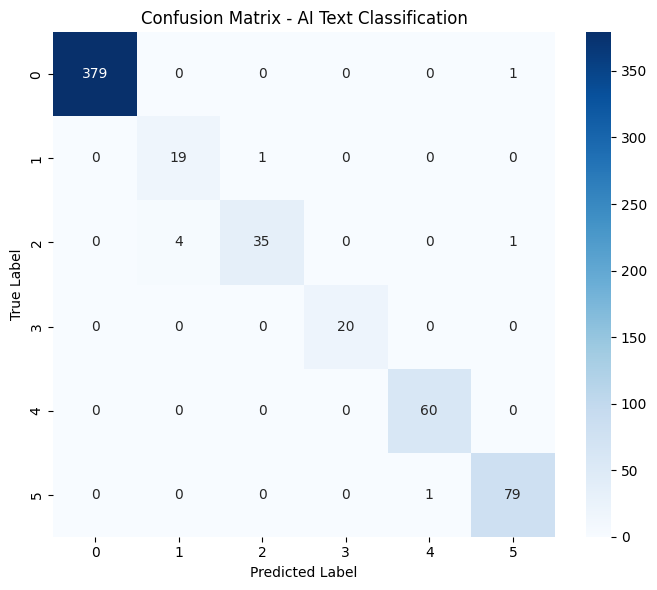

In [ ]:
# ==============================================================================
# VISUALIZATION: CONFUSION MATRIX
# ==============================================================================
# I create a confusion matrix to show which AI models are confused with each other

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# I create the confusion matrix with proper class ordering
cm = confusion_matrix(
    y_test, 
    y_pred, 
    labels=["Human", 'DeepSeek', 'Grok', 'Claude', 'Gemini', 'ChatGPT']
)

# I visualize with heatmap
ax = sns.heatmap(cm, cmap='Blues', annot=True, fmt='.3g')
ax.set_title('Confusion Matrix - AI Text Classification')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Final Submission: Full Pipeline on Complete Training Data

To maximize performance on the official test set, I retrain on the complete training data (combining my internal train and validation sets). This is safe because:
1. I've already tuned hyperparameters and selected the model architecture
2. The internal validation set was only used for final model selection
3. Using all available training data typically improves performance

In [ ]:
# ==============================================================================
# FINAL SUBMISSION: TRAIN ON FULL DATA AND PREDICT ON TEST SET
# ==============================================================================

# I create the complete pipeline: preprocessing + stacking model
full_pipeline = Pipeline([
    ('preprocessing_ext', pipeline),  # Feature extraction + ImpCHI + Scaling
    ('model', stacking_clf)  # Stacking ensemble with calibration
])

# I extract all available training data
X, y = train['TEXT'], train['LABEL']

# Train the complete pipeline on ALL training data
print("Training final model on complete training set...")
print(f"Total training samples: {X.shape[0]}")
full_pipeline.fit(pd.DataFrame(X), y)
print("Final model training completed")

# Generate predictions on the official test set
print("\nGenerating predictions on official test set...")
test_preds = full_pipeline.predict(pd.DataFrame(test['TEXT']))

# I create the submission file in the required format
# Required columns: ID, LABEL
submission = pd.DataFrame({
    'ID': np.arange(test.shape[0]),
    'LABEL': test_preds
})

# Save submission
submission.to_csv('submission.csv', index=False)
print(f"Submission saved: {submission.shape[0]} predictions")

print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"1. Feature Engineering: ImpCHI + n-grams")
print(f"2. Base Models: 2 x LightGBM (Trial 31 + Trial 8)")
print(f"3. Calibration: Isotonic (5-fold CV)")
print(f"4. Meta-Learner: Logistic Regression")
print(f"5. Final Predictions: Stacking Classifier")
print(f"6. Submitted for {test.shape[0]} test samples")

Training final model on complete training set...
Total training samples: 2400
Fitting TF-IDF (min_df=3, ngrams=(1, 3))...
Selecting top 45 features per label via Chi-Square test...
Total unique TF-IDF features selected: 256
✓ Final model training completed

Generating predictions on official test set...


c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: U

Submission saved: 600 predictions

Submission preview (first 5 rows):
   ID  LABEL
0   0      0
1   1      0
2   2      0
3   3      0
4   4      0

PIPELINE SUMMARY
1. Feature Engineering: ImpCHI + n-grams
2. Base Models: 2 x LightGBM (Trial 31 + Trial 8)
3. Calibration: Isotonic (5-fold CV)
4. Meta-Learner: Logistic Regression
5. Final Predictions: Stacking Classifier
6. Submitted for 600 test samples


c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\gianb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
